In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import binned_statistic

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'  
plt.rcParams['font.family'] = 'serif'

In [77]:
data = np.loadtxt('/Users/pablovazquez/GALA_hole/build/excitPos5_Xe4bar_100ev_grid.txt')

In [78]:
data = pd.DataFrame(data, columns=['event_id', 'x', 'y', 'z', 'time'])

In [79]:
data

,event_id,x,y,z,time
0,0.0,0.794892,0.468623,1.082590,4074.74
1,0.0,0.804224,0.454082,1.082060,4145.65
2,0.0,0.787108,0.371149,1.056060,4641.64
3,0.0,0.784974,0.366582,1.061450,4651.48
4,0.0,0.786341,0.359275,1.055250,4685.04
...,...,...,...,...,...
5078,99.0,-0.794590,0.089736,0.035380,6797.65
5079,99.0,-0.802186,0.084186,0.037222,6826.24
5080,99.0,-0.804413,0.081506,0.038314,6832.40
5081,99.0,-0.810161,0.072107,0.033310,6876.78


In [80]:
data

,event_id,x,y,z,time
0,0.0,0.794892,0.468623,1.082590,4074.74
1,0.0,0.804224,0.454082,1.082060,4145.65
2,0.0,0.787108,0.371149,1.056060,4641.64
3,0.0,0.784974,0.366582,1.061450,4651.48
4,0.0,0.786341,0.359275,1.055250,4685.04
...,...,...,...,...,...
5078,99.0,-0.794590,0.089736,0.035380,6797.65
5079,99.0,-0.802186,0.084186,0.037222,6826.24
5080,99.0,-0.804413,0.081506,0.038314,6832.40
5081,99.0,-0.810161,0.072107,0.033310,6876.78


In [81]:
exc = data.groupby('event_id').size()
normalized_exc = (exc / np.mean(exc.to_numpy())).to_numpy()

In [82]:
data['z'] = data['z'] - 0.5
data = data[(data.x > -0.25) & (data.x < 0.25) & (data.z > -0.25) & (data.z < 0.25)]

In [83]:
mean_x = data.groupby('event_id')['x'].mean()
mean_z = data.groupby('event_id')['z'].mean() 
event_length = data.groupby('event_id')
event_times = data.groupby('event_id')['time'].max() -  data.groupby('event_id')['time'].min()

In [95]:
mean_R = mean_x.to_numpy()**2 + mean_z.to_numpy()**2


0.07355030405562805

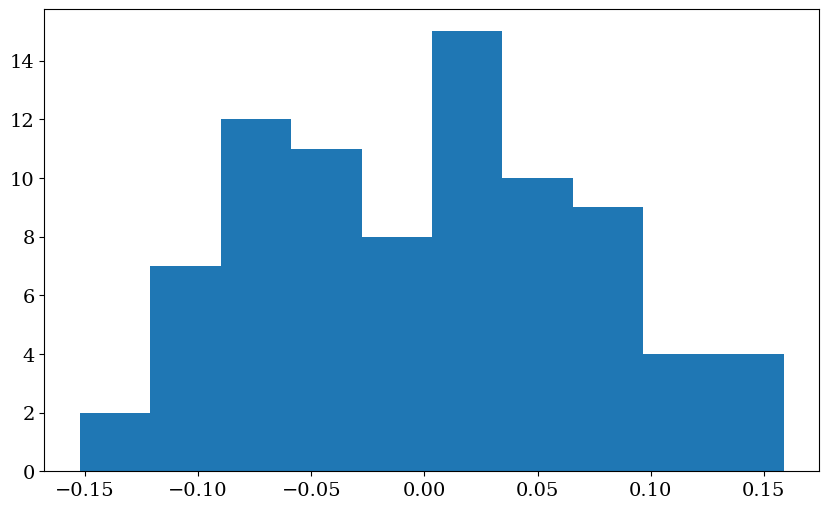

In [98]:
plt.hist(mean_x)
np.std(mean_x)

Eventos analizados: 100
Pearson r = 0.615, p = 1.040e-11
Spearman rho = 0.610, p = 1.583e-11


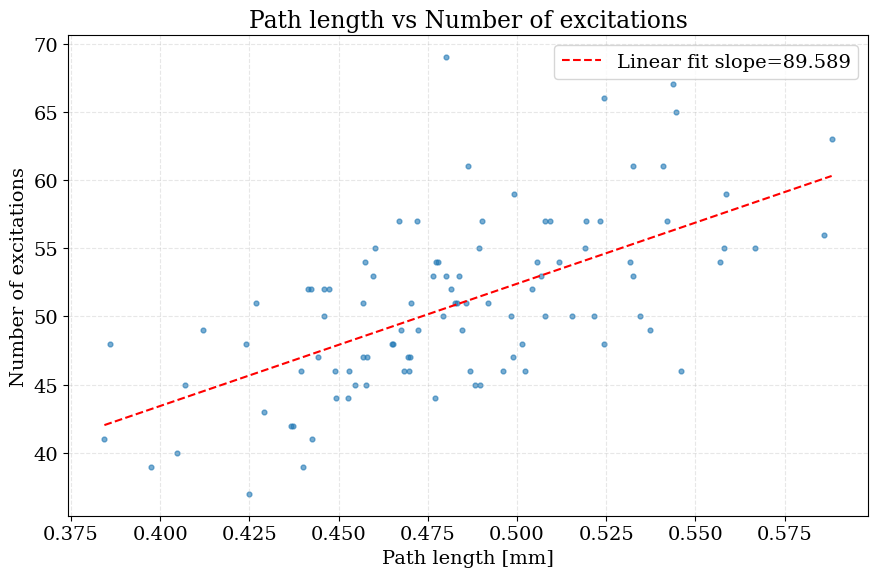


Primeras filas de `events`:
   event_id  path_length_mm  n_excitations  duration_ns  exc_per_mm
0       0.0        0.532522             61      1811.40  114.549229
1       1.0        0.404793             40      1411.34   98.815862
2       2.0        0.490315             57      1715.31  116.251853
3       3.0        0.489444             55      1577.42  112.372463
4       4.0        0.588149             63      1857.91  107.115760


In [41]:
# Calcular longitud de camino por evento y analizar correlación con número de excitaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# función que calcula la longitud de camino (mm) para un grupo de hits ordenados por tiempo
def path_length_for_group(g):
    coords = g.sort_values('time')[['x','y','z']].to_numpy()
    if coords.shape[0] < 2:
        return 0.0
    diffs = np.linalg.norm(np.diff(coords, axis=0), axis=1)
    return float(diffs.sum())

# calcular longitud por evento
event_length = data.groupby('event_id').apply(path_length_for_group)

# número de excitaciones por evento
exc_series = data.groupby('event_id').size()

# duración del evento (ns)
event_duration = data.groupby('event_id')['time'].agg(lambda s: s.max() - s.min())

# Construir DataFrame con resultados
events = pd.DataFrame({
    'event_id': event_length.index,
    'path_length_mm': event_length.values,
    'n_excitations': exc_series.reindex(event_length.index).fillna(0).astype(int).values,
    'duration_ns': event_duration.reindex(event_length.index).fillna(0).values
})

# Correlaciones
mask = (events['path_length_mm'] > 0) & (events['n_excitations'] >= 0)
if mask.sum() >= 2:
    r_p, p_p = pearsonr(events.loc[mask, 'path_length_mm'], events.loc[mask, 'n_excitations'])
    r_s, p_s = spearmanr(events.loc[mask, 'path_length_mm'], events.loc[mask, 'n_excitations'])
else:
    r_p = r_s = p_p = p_s = np.nan

print(f"Eventos analizados: {len(events):,}")
print(f"Pearson r = {r_p:.3f}, p = {p_p:.3e}")
print(f"Spearman rho = {r_s:.3f}, p = {p_s:.3e}")

# Gráfico: path length vs n_excitations
plt.figure(figsize=(9,6))
plt.scatter(events['path_length_mm'], events['n_excitations'], s=12, alpha=0.6)
if mask.sum() >= 2:
    m, b = np.polyfit(events.loc[mask, 'path_length_mm'], events.loc[mask, 'n_excitations'], 1)
    xs = np.linspace(events['path_length_mm'].min(), events['path_length_mm'].max(), 200)
    plt.plot(xs, m*xs + b, 'r--', label=f'Linear fit slope={m:.3f}')
    plt.legend()

plt.xlabel('Path length [mm]')
plt.ylabel('Number of excitations')
plt.title('Path length vs Number of excitations')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Añadir columnas al dataframe 'events' y mostrar un resumen
events['exc_per_mm'] = events['n_excitations'] / events['path_length_mm'].replace(0, np.nan)
print('\nPrimeras filas de `events`:')
print(events.head())


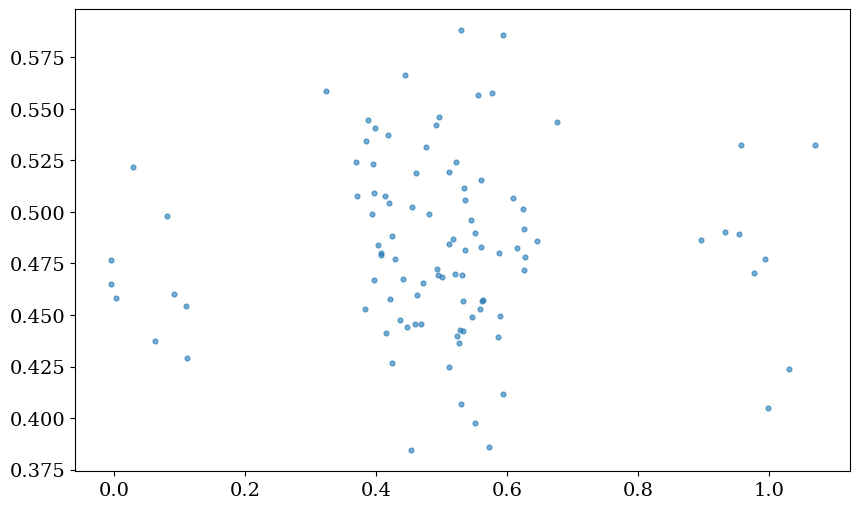

In [46]:
plt.scatter(mean_z, events['path_length_mm'], s=12, alpha=0.6)

In [33]:
radius = np.sqrt(mean_x.to_numpy()**2 + mean_z.to_numpy()**2)

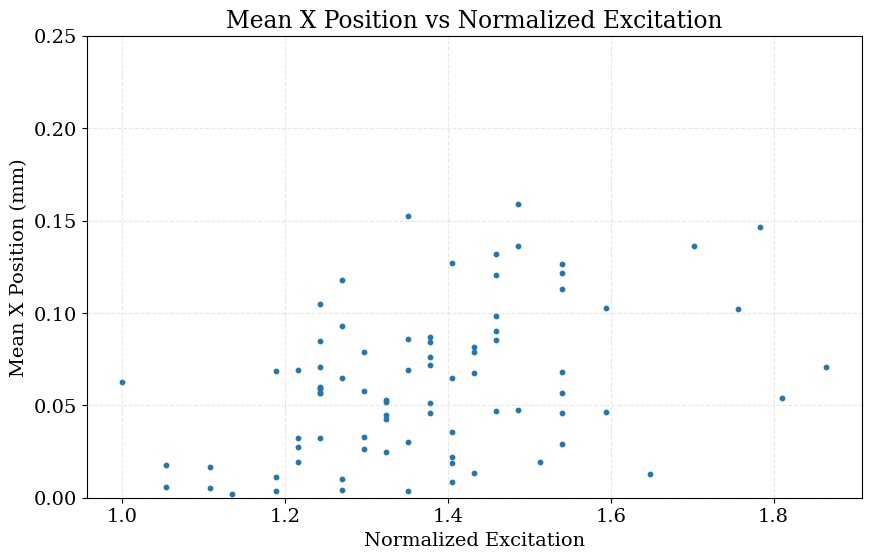

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(exc/np.min(exc), abs(mean_x), s=10)
plt.ylim(0, 0.25)
plt.xlabel('Normalized Excitation')
plt.ylabel('Mean X Position (mm)')
plt.title('Mean X Position vs Normalized Excitation')
plt.grid(True, alpha = 0.3, linestyle = '--')

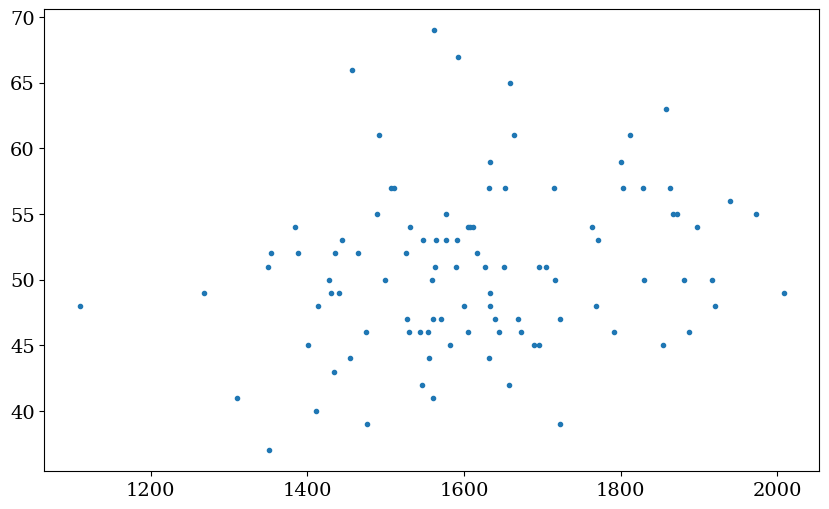

In [39]:
plt.plot(event_times, exc, '.');